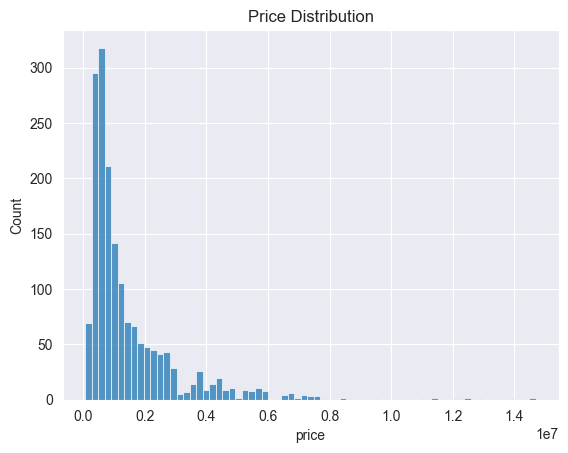

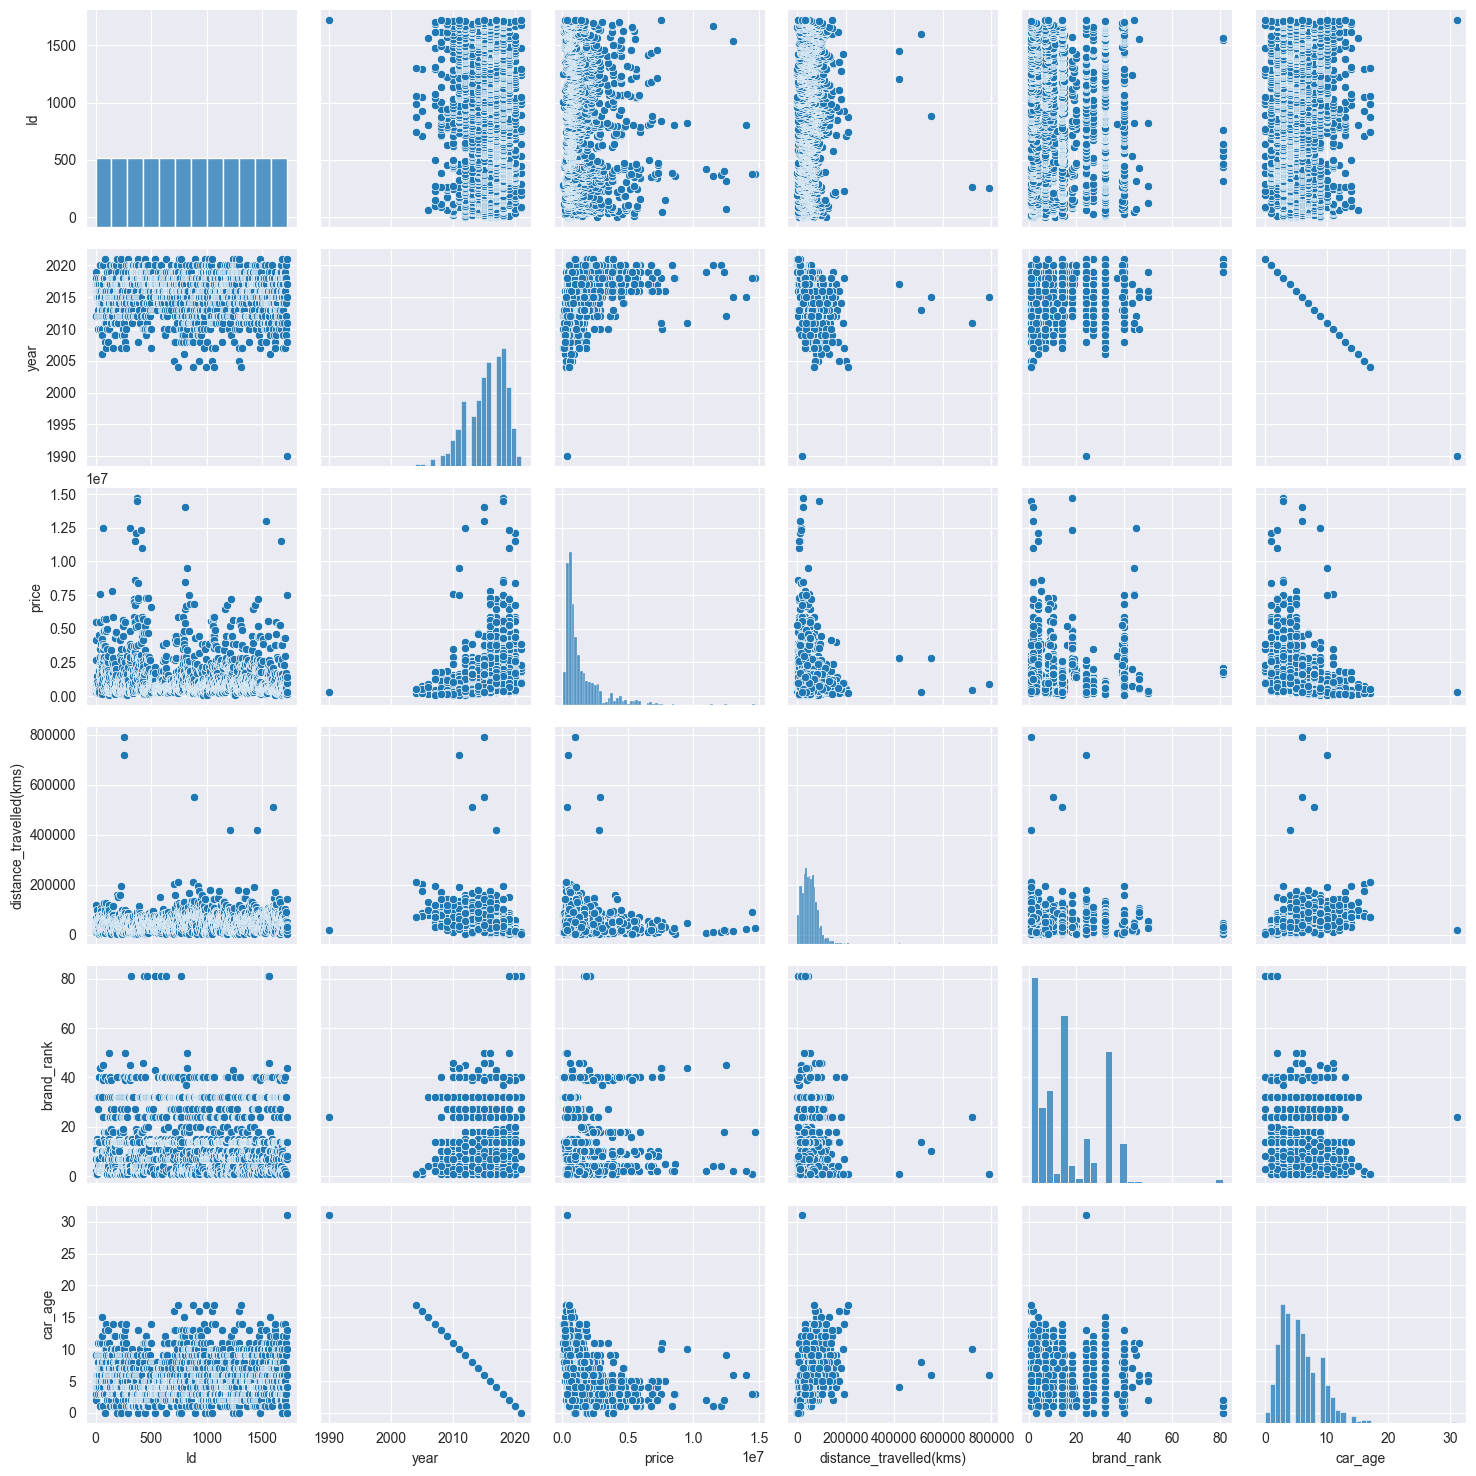

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Load the dataset
df = pd.read_csv('cars.csv')

# Exploratory Data Analysis
# Univariate Analysis
sns.histplot(df['price'])
plt.title('Price Distribution')
plt.show()

# Multivariate Analysis
sns.pairplot(df)
plt.show()

# Data Preprocessing
# Handling missing values
df = df.dropna()

# Convert categorical data to numerical data using OneHotEncoder
categorical_features = ['brand', 'fuel_type', 'city']
encoder = OneHotEncoder(sparse=False, drop='first')
encoded_features = encoder.fit_transform(df[categorical_features])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Drop original categorical columns and concatenate encoded columns
df = df.drop(categorical_features, axis=1)
df = pd.concat([df, encoded_df], axis=1)

# Separate features and target variable
X = df.drop(['price', 'Id', 'full_model_name'], axis=1)
y = df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

# Feature importance
importance = model.coef_
features = X.columns
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)
